### 6/23/26 just checking to see if the output is normal

## Background

The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

Note that a general equation for the diascalar material transformation for a process $P$ for a water mass $\mathcal{M}$ defined to be all tracer $\lambda$ values greater than $\tilde \lambda$. The convergence of a flux $\mathcal{F} = \nabla \cdot \mathbf{F}$.

$$
    \mathcal{G}_{\ge}^{\text{(P)}} = \int_{\mathcal{A_R}(\tilde\lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \mathcal{F} \, \text{d}S = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
$$

And the subsequent diascalar material transformation demonstrating a relationship between mixing calculated as a convergence of a diffusive flux and mixing calculated as tracer variance decay is

*tbh, idk if this is the equation they use, but this is the equation I derived in my advancement proposal*
$$
\begin{equation}
\mathcal{G}^{\text{(phy)}} = \underbrace{\int_{\mathcal{A_R}(\tilde \lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \left(- \nabla \cdot \left(-\kappa_{phy} \nabla \lambda\right)\right) \, \text{d}S}_{\text{mixing as conv. of diff. flux}} = \underbrace{-\frac{1}{2} \frac{\partial^2}{\partial \tilde\lambda^2}\left[ \int_{\Omega(\tilde\lambda ,t)} \rho \left( 2 \kappa_{phy} \vert\vert \nabla \lambda \vert\vert^2\right) \, \text{d}V\right]}_{\text{mixing as var. decay}} 
\tag{2}
\end{equation}
$$ 


While Castro et al. describes a relationship between the convergence of a diffusive tracer flux and tracer variance decay for *phyiscal* mixing, we propose to look at *numerical* mixing through a similar framework. This relationship would look very similar to Equation 2, but our we would instead be solving for the term $\mathcal{G}^{\text{(num)}}$ and the diffusivities would be $\kappa_{num}$ rather than $\kappa_{phy}$. 

### Mixing as convergence of a diffusive flux
We quickly run into a problem, which is that $\kappa_{num}$ is unknown when calculating the nuemrical mixing as the convergence of a diffusive flux. Recall that $\kappa_{phy}$ comes from a prescribed background diffusivity. In which case, we need a different way to calculate $\mathcal{G}^{\text{(num)}}$. We propose to do so using the WMT budget residual.

$$
\begin{align}
    \partial_t{\mathcal{M}} &= \Psi + \mathcal{S} + \mathcal{G^{\text{(BF)}}} + \mathcal{G^{\text{(phy)}}} + \mathcal{G^{\text{(num)}}} \\
    \implies \mathcal{G^{\text{(num)}}} & = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}}
    \tag{3}
\end{align} 
$$

### Mixing as tracer variance decay
We *can*, however, calculate a $\kappa_{num}$ when thinking about numerical mixing through the perspective of tracer variance decay, if we use the Discrete Varaince Decay (DVD) algorithm.
Let 
$$
\begin{equation}
	\chi^{\text{(num)}} = \underbrace{\frac{A\{\left(\lambda_i^n\right)^2\} -\left[A\{\lambda_i^n\}\right]^2}{\Delta t}}_{\text{DVD}} = \underbrace{-2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}}_{\substack{\text{discretized mixing}\\\text{as variance decay}}} \approx \underbrace{-2 \kappa_{num}\left(\frac{\partial \lambda}{\partial x}\right)^2}_{\substack{\text{continuous mixing}\\\text{as variance decay}}} \tag{4}
\end{equation}
$$

The $\kappa_{num}$ arises out of the mathematical manipulation of the advection operator to get the rest of thet algorithm.
$$
    \kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x}\right) \tag{5}
$$

The $\chi^{\text{(num)}}$ term is a tendency that can now be written in the WMT framework as 
$$
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
$$

### WMT relationship of numerical mixing as a budget residual and as tracer variance decay.
The following relationship (in terms of the WMT framework) between Equations 2 and 3 then emerges.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi \, \text{d}V\right] \tag{7}
\end{equation}
$$

*do NOT trust the signs in this argument, it depends on the direction you're integrating, and I'm sure I have several sign errors rn*

In [202]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid

### Open files & visualize raw data

In [203]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
ds_wmt = xr.open_dataset(filepath + 'analysis_members/10km_channel_WMT_Monthly.0001-01-01.nc')
mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [204]:
for i in ds_wmt.data_vars:
    if 'Mix' in i:
        print(i)

temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency


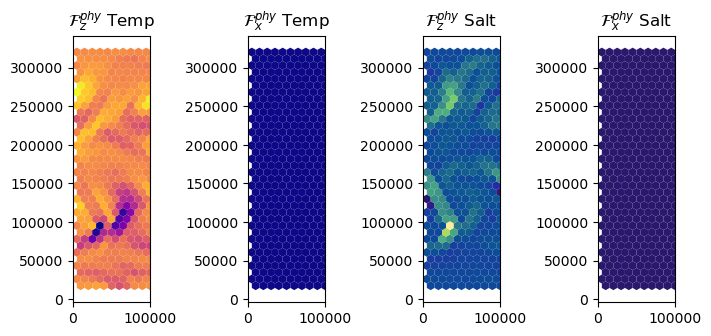

In [205]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))

mosaic.polypcolor(ax[0],descriptor, ds_wmt.temperatureVertMixTendency.isel(Time=15, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[1],descriptor, ds_wmt.temperatureHorMixTendency.isel(Time=15, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[2],descriptor, ds_wmt.salinityVertMixTendency.isel(Time=15, nVertLevels=1),cmap='cmo.haline')
mosaic.polypcolor(ax[3],descriptor, ds_wmt.salinityHorMixTendency.isel(Time=15, nVertLevels=0),cmap='cmo.haline')
ax[0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[1].set_title(r'$\mathcal{F}^{phy}_{x}$ Temp')
ax[2].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')
ax[3].set_title(r'$\mathcal{F}^{phy}_{x}$ Salt')

for i in range(0,4):
    ax[i].set_aspect(1.0)

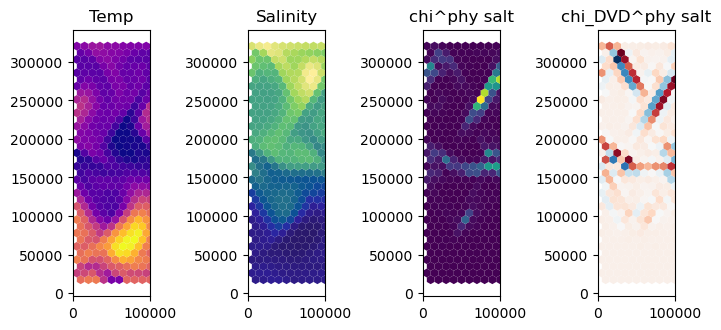

In [206]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))


#mosaic.polypcolor(ax[0,0], descriptor, region00_plan.isel(Time = time_idx), cmap='RdBu_r', vmin=-cbar_value, vmax=cbar_value)
mosaic.polypcolor(ax[0],descriptor, ds_output.temperature.isel(Time=300, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[1],descriptor, ds_output.salinity.isel(Time=300, nVertLevels=0), cmap='cmo.haline')
mosaic.polypcolor(ax[2],descriptor, ds_dvd.chiPhyVerSalt.isel(Time=300, nVertLevelsP1=1))
mosaic.polypcolor(ax[3],descriptor, ds_dvd.chiSpurSaltBR08.isel(Time=300, nVertLevels=0),cmap='RdBu_r')
ax[0].set_title('Temp')
ax[1].set_title('Salinity')
ax[2].set_title('chi^phy salt')
ax[3].set_title('chi_DVD^phy salt')

for i in range(0,4):
    ax[i].set_aspect(1.0)

## Explanation of data


|Dataset Name|Description|
|--| --|
|`ds_output` | standard output variables (T, S, velo)|
|`ds_dvd` | $\chi^{\text{(phy)}}$ and $\chi^{\text{(num)}}$ from DVD alg.|
|`ds_wmt` | $\mathcal{F} \,; [^\circ C s^{-1}]$ ; conv. of diff. flux |
|`mesh` | grid variables (cellsOnEdge, etc) |

>- Simulations were run with a linear equation of state such that $\rho_0 = 1027 \, kg/m^3$ $\leftarrow$ CHECK THIS 
>- No prescribed horizontal mixing $\kappa_{phy,x} = 0$, so we expect `TracerHorMixTendency` to be 0 (`dvd_wmt` dataset).
>- Vertical mixing is prescribed using KPP where the background diffusivity is $\kappa_{phy,z} = 10e-5 \, m^2s^{-1}$.
>- The background viscosity is set to $\nu = 10e-4 \, m^2 s^{-1}$.
>- Only wind stress forcing is prescribed.
>- The `TracerSurfaceFluxTendency` in the `dvd_wmt` dataset is 0 because we do not have any boundary forcing that would introduce tracers at the surface.

The $\mathcal{F}$ and $\chi$ outputs require that we calculate $\mathcal{G}^{\text{(phy)}}$ and $\mathcal{G}^{\text{(num)}}$ offline. The following math is necessary.

*Recall that in order to calculate the residual, we need to directly calculate all other terms in the budget*

We need to plug in $\mathcal{F}$ (`TracerVertMixTendency`) into Equation 1.
$$
\begin{equation}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
\end{equation}
$$

We need to plug in $\chi^{\text{(num)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i+1} - \tilde\lambda_i}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*again, this was sloppy and it is very possible there is a sign error.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class. 

In [207]:
## SOMETHING IS WRONG I JUST DON'T KNOW WHAT YET

In [308]:
ds_wmt

<xarray.Dataset> Size: 80MB
Dimensions:                                               (Time: 30,
                                                           nCells: 360,
                                                           nVertLevels: 50)
Dimensions without coordinates: Time, nCells, nVertLevels
Data variables: (12/42)
    temperatureTend                                       (Time, nCells, nVertLevels) float64 4MB ...
    salinityTend                                          (Time, nCells, nVertLevels) float64 4MB ...
    temperatureHorizontalAdvectionTendency                (Time, nCells, nVertLevels) float64 4MB ...
    salinityHorizontalAdvectionTendency                   (Time, nCells, nVertLevels) float64 4MB ...
    temperatureVerticalAdvectionTendency                  (Time, nCells, nVertLevels) float64 4MB ...
    salinityVerticalAdvectionTendency                     (Time, nCells, nVertLevels) float64 4MB ...
    ...                                                    ...
    passiveTemperatureSquaredSurfaceFluxSubglacialRunoff  (Time, nCells) float64 86kB ...
    passiveSalinitySquaredSurfaceFluxSubglacialRunoff     (Time, nCells) float64 86kB ...
    passiveTemperatureSurfaceFluxRemoved                  (Time, nCells) float64 86kB ...
    passiveSalinitySurfaceFluxRemoved                     (Time, nCells) float64 86kB ...
    passiveTemperatureSquaredSurfaceFluxRemoved           (Time, nCells) float64 86kB ...
    passiveSalinitySquaredSurfaceFluxRemoved              (Time, nCells) float64 86kB ...
Attributes: (12/1365)
    model_name:                                                      mpas
    core_name:                                                       ocean
    source:                                                          MPAS
    Conventions:                                                     MPAS
    git_version:                                                     unknown
    on_a_sphere:                                                     NO
    ...                                                              ...
    config_rx1_slope_weight:                                         0.1
    config_rx1_zstar_weight:                                         1.0
    config_rx1_horiz_smooth_open_ocean_cells:                        20
    config_rx1_min_levels:                                           3
    config_rx1_min_layer_thickness:                                  1.0
    file_id:                                                         2i7u0xnu5m

In [310]:
# calculate the integrand
time_idx = 15
rho_0 = 1026 # kg/m^3
dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
integrand = ds_wmt.salinityVertMixTendency.isel(Time=time_idx) * rho_0 * dV


In [312]:
# define target coords
target_coords = np.arange(30,56,0.5)
dlambda = target_coords[1] - target_coords[0]

# set up salinity data to be target coords
# not for this set up, but good practice in case there's topography
# fill the bottom cell with the same value as the one above it (so it is no longer a nan)
ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# interpolate data onto nVertLevelsP1 
grid = Grid(ds_output, coords={'Z': {'center': 'nVertLevels', 'outer':'nVertLevelsP1'}}, periodic = False, autoparse_metadata=False)

# interpolate
ds_output['salinity_P1'] = grid.interp(ds_output.salinity, 'Z', boundary='extend')

# transform
ds_output_salinity_mix_tendencyX_transformed = grid.transform(integrand,
                                                             'Z',
                                                             target_coords,
                                                             method= 'conservative',
                                                             target_data = ds_output.salinity_P1.isel(Time=360))
                                                             # target_data = ds_output.salinity_P1.isel(Time=300))

In [313]:
# then calculate the derivative
# create an array
G_phy = np.zeros(len(target_coords))

for i in range(0,len(target_coords)-2):
    d_tracerMassFlux = ds_output_salinity_mix_tendencyX_transformed[:,i+1].sum() - ds_output_salinity_mix_tendencyX_transformed[:,i].sum()
    d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
    G_phy[i] = d_tracerMassFlux_dlambda
    
    

## improved plots, but need a more robust way to determine the target coordinates
(need to rerun simulations so time steps match)
need to decide averaging period, output periods

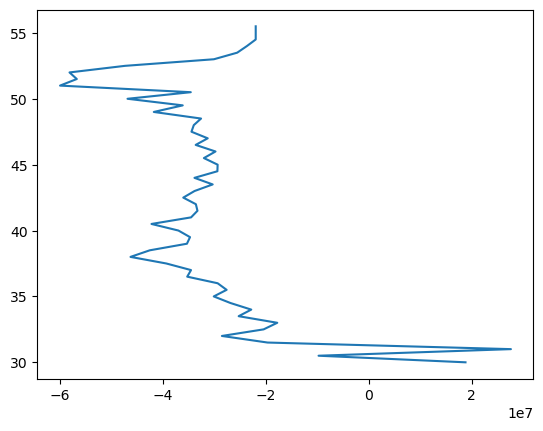

In [315]:
plt.plot(np.cumsum(G_phy), target_coords)

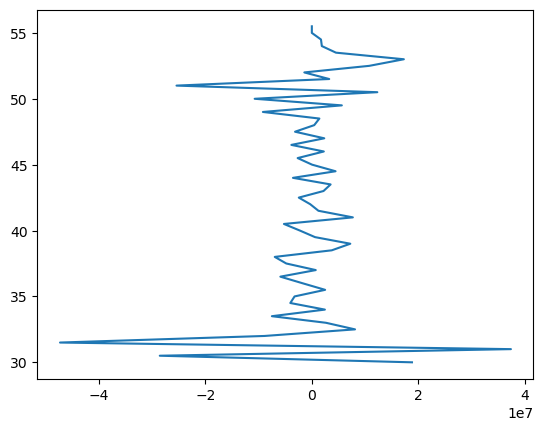

In [316]:
plt.plot(G_phy, target_coords)